In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv(
    "../data/processed/customer_clean.csv"
)

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [7]:
cluster_df = df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

In [8]:
cluster_df = pd.get_dummies(
    cluster_df,
    drop_first=True
)


In [9]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_df
)

In [10]:
joblib.dump(
    scaler,
    "../models/cluster_scaler.pkl"
)

['../models/cluster_scaler.pkl']

In [11]:
inertia=[]

k_values=range(2,11)

for k in k_values:

    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)

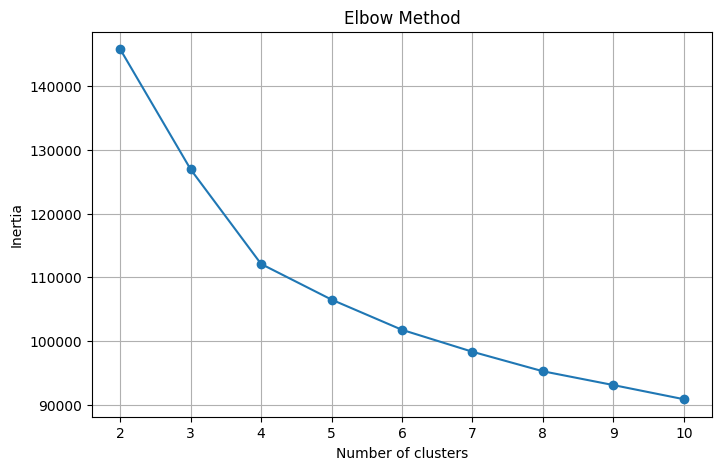

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")
plt.grid(True)

plt.savefig(
    "../reports/segmentation/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)

In [14]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

['../models/kmeans_model.pkl']

In [15]:
df["Cluster"] = clusters

In [16]:
df["Cluster"].value_counts()

Cluster
1    2735
2    2100
3    1526
0     682
Name: count, dtype: int64

In [17]:
cluster_summary = df.groupby(
    "Cluster"
).mean(numeric_only=True)

cluster_summary

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Cluster,,,,
0,0.152493,31.737537,42.028592,1500.131818
1,0.215356,15.538208,73.985356,1172.303007
2,0.189048,55.825238,91.874429,5153.658357
3,0.034076,30.547182,21.079194,668.099443


In [18]:
cluster_summary.to_csv(
    "../reports/segmentation/cluster_summary.csv"
)

In [19]:
pca = PCA(
    n_components=2,
    random_state=42
)

pca_data = pca.fit_transform(
    scaled_data
)

pca_data

array([[-0.43230228, -3.1502016 ],
       [-0.20386419, -0.7943274 ],
       [-0.16026533, -2.0897877 ],
       ...,
       [-0.34196034, -2.48542844],
       [-0.61640292, -2.04990187],
       [-3.0090733 ,  2.2503948 ]], shape=(7043, 2))

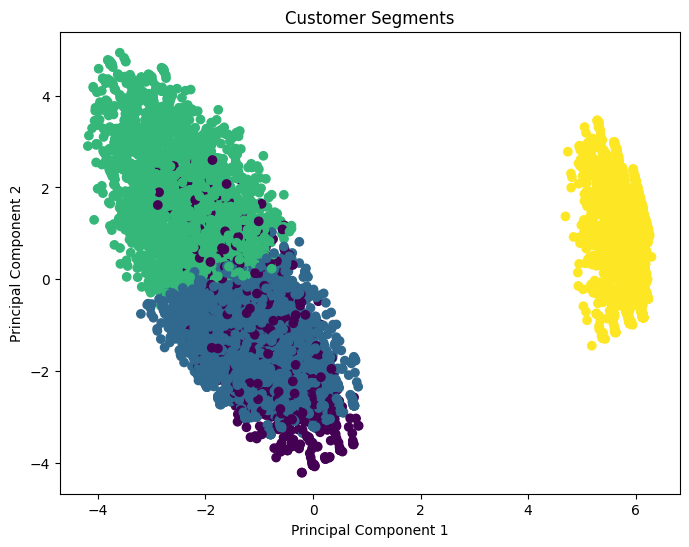

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Customer Segments")

plt.savefig(
    "../reports/segmentation/cluster_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
df.to_csv(
    "../reports/segmentation/clustered_customers.csv",
    index=False
)